In [86]:
import pandas as pd
import re

# Завантажуємо дані
df = pd.read_excel('En_In.xls', skiprows=17, usecols=[1, 3, 4, 5])

pd.set_option('display.max_rows', None)  # Це дозволить показати всі рядки

df.columns = ['Country', 'Energy Supply', 'Energy Supply per Capita', '% Renewable']

df.dropna(how='all', inplace=True)

df.index = range(1, len(df) + 1)

# 1. Замінюємо некоректні значення ('...') на NaN
df['Energy Supply'] = pd.to_numeric(df['Energy Supply'], errors='coerce')

# 2. Переводимо значення з ПДж у ГДж (1 ПДж = 1 000 000 ГДж)
df['Energy Supply'] = df['Energy Supply'] * 1000000

rename_countries = {
    "Republic of Korea": "South Korea",
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "China, Hong Kong Special Administrative Region": "Hong Kong"
}

df['Country'] = df['Country'].replace(rename_countries)

# Функція для видалення цифр та тексту в дужках
def clean_country_name(country):
    if isinstance(country, str):  # Перевіряємо, чи є country рядком
        country = re.sub(r'\s*\(.*?\)', '', country)  # Видаляємо текст у дужках
        country = re.sub(r'\d+', '', country)  # Видаляємо цифри
        return country.strip()  # Видаляємо зайві пробіли
    return country  

df['Country'] = df['Country'].map(clean_country_name)

df.head(227)


,Country,Energy Supply,Energy Supply per Capita,% Renewable
1,Afghanistan,3.210000e+08,10,78.669280
2,Albania,1.020000e+08,35,100.000000
3,Algeria,1.959000e+09,51,0.551010
4,American Samoa,NaN,...,0.641026
5,Andorra,9.000000e+06,121,88.695650
6,Angola,6.420000e+08,27,70.909090
7,Anguilla,2.000000e+06,136,0.000000
8,Antigua and Barbuda,8.000000e+06,84,0.000000
9,Argentina,3.378000e+09,79,24.064520
10,Armenia,1.430000e+08,48,28.236060


In [90]:
import pandas as pd

pd = pd.read_csv('gpd.csv', header=None, skiprows=5)

pd.columns = ['Country', 'Country Code', 'Indicator Name', 'Indicator Code'] + list(range(1960, 2016))

rename_countries = {
    "Korea, Rep.": "South Korea",
    "Iran, Islamic Rep.": "Iran",
    "Hong Kong SAR, China": "Hong Kong"
}

pd['Country'] = pd['Country'].replace(rename_countries)

pd.head(1)


,Country,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,Aruba,ABW,GDP at market prices (constant 2010 US$),NY.GDP.MKTP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.467704e+09,NaN,NaN,NaN,NaN,NaN


In [96]:
import pandas as pd

file_path = 'scimagojr.xlsx'  

df = pd.read_excel(file_path)

print(df.head())

   Rank             Country  Documents  Citable documents  Citations  \
0     1               China     127050             126767     597237   
1     2       United States      96661              94747     792274   
2     3               Japan      30504              30287     223024   
3     4      United Kingdom      20944              20357     206091   
4     5  Russian Federation      18534              18301      34266   

   Self-citations  Citations per document  H index  
0          411683                    4.70      138  
1          265436                    8.20      230  
2           61554                    7.31      134  
3           37874                    9.84      139  
4           12422                    1.85       57  


In [98]:
import pandas as pd
import re

# 1. Завантаження даних з En_In.xls
energy_df = pd.read_excel('En_In.xls', skiprows=17, usecols=[1, 3, 4, 5])
energy_df.columns = ['Country', 'Energy Supply', 'Energy Supply per Capita', '% Renewable']
energy_df.dropna(how='all', inplace=True)
energy_df['Energy Supply'] = pd.to_numeric(energy_df['Energy Supply'], errors='coerce') * 1000000

# Стандартні назви країн
rename_countries_energy = {
    "Republic of Korea": "South Korea",
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "China, Hong Kong Special Administrative Region": "Hong Kong"
}
energy_df['Country'] = energy_df['Country'].replace(rename_countries_energy)

# Очищення назв країн
def clean_country_name(country):
    if isinstance(country, str):
        country = re.sub(r'\s*\(.*?\)', '', country)
        country = re.sub(r'\d+', '', country)
        return country.strip()
    return country

energy_df['Country'] = energy_df['Country'].map(clean_country_name)

# 2. Завантаження даних з gpd.csv
gdp_df = pd.read_csv('gpd.csv', header=None, skiprows=5)
gdp_df.columns = ['Country', 'Country Code', 'Indicator Name', 'Indicator Code'] + list(range(1960, 2016))
rename_countries_gdp = {
    "Korea, Rep.": "South Korea",
    "Iran, Islamic Rep.": "Iran",
    "Hong Kong SAR, China": "Hong Kong"
}
gdp_df['Country'] = gdp_df['Country'].replace(rename_countries_gdp)

# 3. Завантаження даних з Scimagojr
scimagojr_df = pd.read_excel('scimagojr.xlsx')
scimagojr_df = scimagojr_df[scimagojr_df['Rank'] <= 15]

# 4. Вибір даних про ВВП за 10 років
gdp_columns = list(range(2006, 2016))
gdp_df = gdp_df[['Country'] + gdp_columns]

# 5. Об'єднання даних
combined_df = scimagojr_df[['Country', 'Rank', 'Documents', 'Citable documents', 'Citations', 
                              'Self-citations', 'Citations per document', 'H index']].merge(
    energy_df, on='Country', how='inner').merge(gdp_df, on='Country', how='inner')

# 6. Встановлення індексу
combined_df.set_index('Country', inplace=True)

# 7. Перевірка розміру DataFrame
print(combined_df.head(3))
print(combined_df.shape)  

               Rank  Documents  Citable documents  Citations  Self-citations  \
Country                                                                        
China             1     127050             126767     597237          411683   
United States     2      96661              94747     792274          265436   
Japan             3      30504              30287     223024           61554   

               Citations per document  H index  Energy Supply  \
Country                                                         
China                            4.70      138   1.271910e+11   
United States                    8.20      230   9.083800e+10   
Japan                            7.31      134   1.898400e+10   

              Energy Supply per Capita  % Renewable          2006  \
Country                                                             
China                               93     19.75491  3.992331e+12   
United States                      286     11.57098  1.479230e+13 

In [100]:
def task_eight():
    # Обчислюємо середній ВВП за останні 10 років (2006-2015) для кожної країни
    gdp_columns = list(range(2006, 2016))
    combined_df['avgGDP'] = combined_df[gdp_columns].mean(axis=1)
    
    # Сортуємо за спаданням середнього ВВП і повертаємо перші 15 країн
    result = combined_df['avgGDP'].sort_values(ascending=False).head(15)
    
    return result

print(task_eight())


Country
United States         1.536434e+13
China                 6.348609e+12
Japan                 5.542208e+12
Germany               3.493025e+12
France                2.681725e+12
United Kingdom        2.487907e+12
Brazil                2.189794e+12
Italy                 2.120175e+12
India                 1.769297e+12
Canada                1.660647e+12
Russian Federation    1.565459e+12
Spain                 1.418078e+12
Australia             1.164043e+12
South Korea           1.106715e+12
Iran                  4.441558e+11
Name: avgGDP, dtype: float64


In [102]:
def task_nine():
    # Отримуємо 5-ту країну за середнім ВВП з завдання 8
    fifth_country = task_eight().index[4]
    
    gdp_2006 = combined_df.loc[fifth_country, 2006]
    gdp_2015 = combined_df.loc[fifth_country, 2015]
    
    # Обчислюємо зміну ВВП
    gdp_change = gdp_2015 - gdp_2006
    
    return (fifth_country, gdp_change)

print(task_nine())


('France', 153345695364.24023)


In [104]:
def task_ten():
    # Знаходимо країну з максимальним значенням у стовпці `% Renewable`
    max_renewable_country = combined_df['% Renewable'].idxmax()
    max_renewable_value = combined_df['% Renewable'].max()
    
    return (max_renewable_country, max_renewable_value)

print(task_ten())


('Brazil', 69.64803)


In [106]:
def task_eleven(combined_df):
    # Розрахунок населення
    combined_df['Estimated Population'] = combined_df['Energy Supply'] / combined_df['Energy Supply per Capita']
    
    sorted_population = combined_df['Estimated Population'].sort_values(ascending=False)
    
    # Отримання шостої країни за оцінкою населення
    sixth_country = sorted_population.index[5]
    sixth_population = sorted_population.iloc[5]
    
    return (sixth_country, sixth_population)

result = task_eleven(combined_df)
print(result)  

('Japan', 127409395.97315437)


In [81]:
def task_twelve(final_df):
    
    final_df['Citable Documents per Person'] = final_df['Citable documents'] / final_df['Estimated Population']
    
    correlation_matrix = final_df[['Citable Documents per Person', 'Energy Supply per Capita']].corr(method='pearson')
    
    correlation_value = correlation_matrix.loc['Citable Documents per Person', 'Energy Supply per Capita']

    return correlation_value

result = task_twelve(combined_df)
print(result)  

0.7940010435442943


In [108]:
def task_thirteen(combined_df):
    # Обчислення медіани % відновлювальної енергії
    median_renewable = combined_df['% Renewable'].median()
    
    # Створення нового стовпця з 1 або 0
    combined_df['Renewable Indicator'] = (combined_df['% Renewable'] >= median_renewable).astype(int)
    
    sorted_result = combined_df.sort_values(by='Rank')['Renewable Indicator']
    
    return sorted_result

result = task_thirteen(combined_df)
print(result)  

Country
China                 1
United States         0
Japan                 0
United Kingdom        0
Russian Federation    1
Canada                1
Germany               1
India                 0
France                1
South Korea           0
Italy                 1
Spain                 1
Iran                  0
Australia             0
Brazil                1
Name: Renewable Indicator, dtype: int64


In [59]:
def task_fourteen(combined_df):
    # Словник для групування країн за континентами
    ContinentDict = {
        'China': 'Asia',
        'United States': 'North America',
        'Japan': 'Asia',
        'United Kingdom': 'Europe',
        'Russian Federation': 'Europe',
        'Canada': 'North America',
        'Germany': 'Europe',
        'India': 'Asia',
        'France': 'Europe',
        'South Korea': 'Asia',
        'Italy': 'Europe',
        'Spain': 'Europe',
        'Iran': 'Asia',
        'Australia': 'Australia',
        'Brazil': 'South America'
    }

    # Додавання стовпця континенту до DataFrame
    combined_df['Continent'] = combined_df.index.map(ContinentDict)

    result = combined_df.groupby('Continent')['Estimated Population'].agg(
        size='count',
        sum='sum',
        mean='mean',
        std='std'
    )

    return result

result = task_fourteen(combined_df)
print(result) 

               size               sum              mean           std
Continent                                                            
Asia              5   2898666386.6106   579733277.32212  6.790979e+08
Australia         1   23316017.316017   23316017.316017           NaN
Europe            6  457929667.216372   76321611.202729  3.464767e+07
North America     2   352855249.48025  176427624.740125  1.996696e+08
South America     1  205915254.237288  205915254.237288           NaN


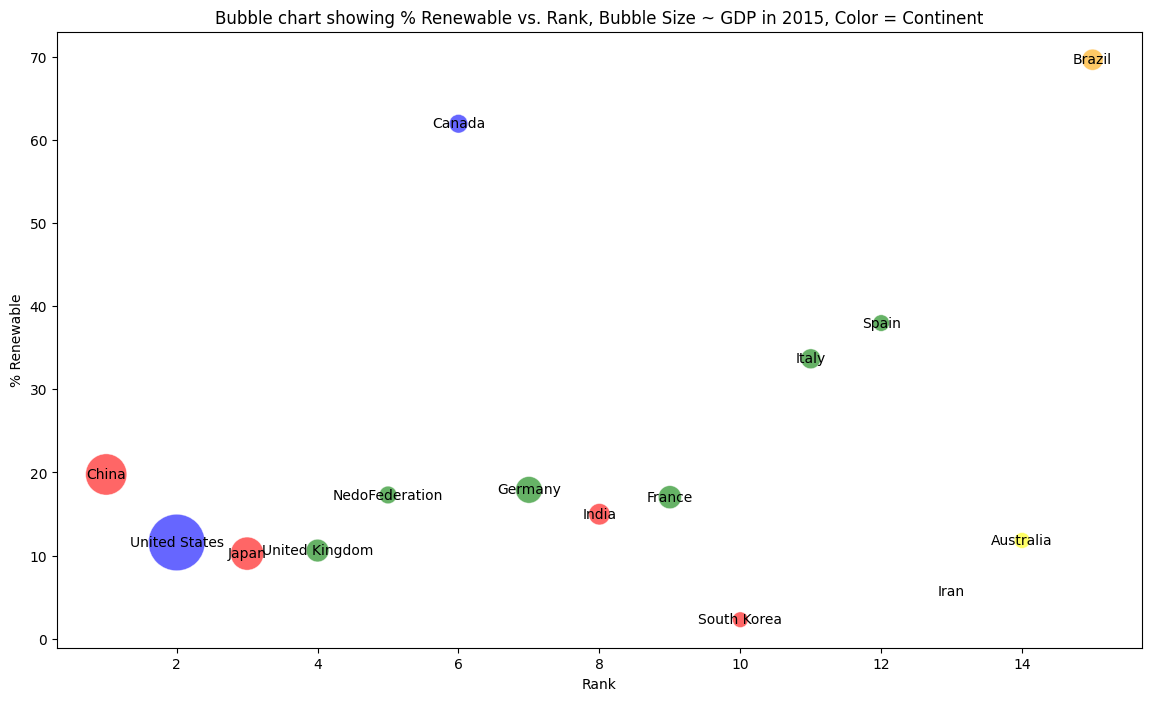

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

continent_colors = {
    'Asia': 'red',
    'Europe': 'green',
    'North America': 'blue',
    'South America': 'orange',
    'Oceania': 'yellow'
}

# Mapping countries to continents
continent_map = {
    'Brazil': 'South America',
    'China': 'Asia',
    'United States': 'North America',
    'Canada': 'North America',
    'Japan': 'Asia',
    'United Kingdom': 'Europe',
    'Germany': 'Europe',
    'France': 'Europe',
    'Italy': 'Europe',
    'Spain': 'Europe',
    'India': 'Asia',
    'Australia': 'Oceania',
    'Russian Federation': 'Europe',
    'South Korea': 'Asia',
    'Iran': 'Asia'
}

combined_df['Continent'] = combined_df.index.map(continent_map)
combined_df['Color'] = combined_df['Continent'].map(continent_colors)

plt.figure(figsize=(14, 8))
plt.scatter(combined_df['Rank'], combined_df['% Renewable'], 
            s=combined_df[2015] / 1e10,  
            c=combined_df['Color'], alpha=0.6, edgecolors="w", linewidth=0.5)

for country in combined_df.index:
    label = "NedoFederation" if country == 'Russian Federation' else country
    plt.text(combined_df.loc[country, 'Rank'], 
             combined_df.loc[country, '% Renewable'], 
             label, ha='center', va='center')

plt.xlabel('Rank')
plt.ylabel('% Renewable')
plt.title('Bubble chart showing % Renewable vs. Rank, Bubble Size ~ GDP in 2015, Color = Continent')
plt.show()
